### Imports

In [29]:
import json
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker
import numpy as np

### Functions

In [30]:
COLORS = {
    "Base": "tab:blue",
    "Observation": "tab:orange",
    "Action": "tab:green",
    "Transition": "tab:red",
}

def process_results(path, aggregation_function = np.mean):

    with open(path, 'r') as file:
        data = json.load(file)

    distances = {}
    # returns = {}

    for noise_type in data:

        noise_results = data[noise_type]

        noise_distances = []
        # noise_returns = []

        for run_number in noise_results:
            
            run_results = noise_results[run_number]
            run_distances = []
            # run_returns = []
            
            for noise_level in run_results:

                aggregate_distance = aggregation_function(run_results[noise_level]["distance"])
                # aggregate_return = aggregation_function(run_results[noise_level]["cumulative_reward"])

                run_distances.append(aggregate_distance)
                # run_returns.append(aggregate_return)

            noise_distances.append(run_distances)
            # noise_returns.append(noise_returns)
        
        # distances[noise_type] = np.array(noise_distances)
        # returns[noise_type] = np.array(noise_returns)
        distances[noise_type] = noise_distances
        # returns[noise_type] = noise_returns
            
    return distances

def make_numpy_arrays(distances):
    numpy_distances = {noise_type: np.array(distance_matrix) for noise_type, distance_matrix in distances.items()}
    # numpy_returns = {noise_type: np.array(returns_matrix) for noise_type, returns_matrix in returns.items()}

    return numpy_distances

def plot_data_mean(data, ax, label):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    n = data.shape[0]
    ci = 1.96 * std / np.sqrt(n)
    
    x = np.linspace(0, 1, 10)
    
    line, = ax.plot(x, mean, label=label, color=COLORS[label])
    ax.fill_between(x, mean - ci, mean + ci,
                    alpha=0.2,
                    color=line.get_color())
    
    ax.set_xlabel("Standard deviation of the noise")
    ax.set_ylabel("Mean distance travelled")

def plot_data_median(data, ax, label, lower_q=0.25, upper_q=0.75):
    median = np.median(data, axis=0)
    lower = np.quantile(data, lower_q, axis=0)
    upper = np.quantile(data, upper_q, axis=0)

    x = np.linspace(0, 1, data.shape[1])

    line, = ax.plot(x, median, label=label, color=COLORS[label])
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.2,
        color=line.get_color()
    )

    ax.set_xlabel("Noise factor $\sigma$")
    ax.set_ylabel("Mean distance traveled")

#### Hopper Task

In [31]:
base_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_base_agent_Hopper-v5.json"))
baseppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_baseppo_agent_Hopper-v5.json"))
state_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_state_agent_Hopper-v5.json"))
stateppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_stateppo_agent_Hopper-v5.json"))
action_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_action_agent_Hopper-v5.json"))
# actionppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_actionppo_agent_Hopper-v5.json"))
transition_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_transition_agent_Hopper-v5.json"))

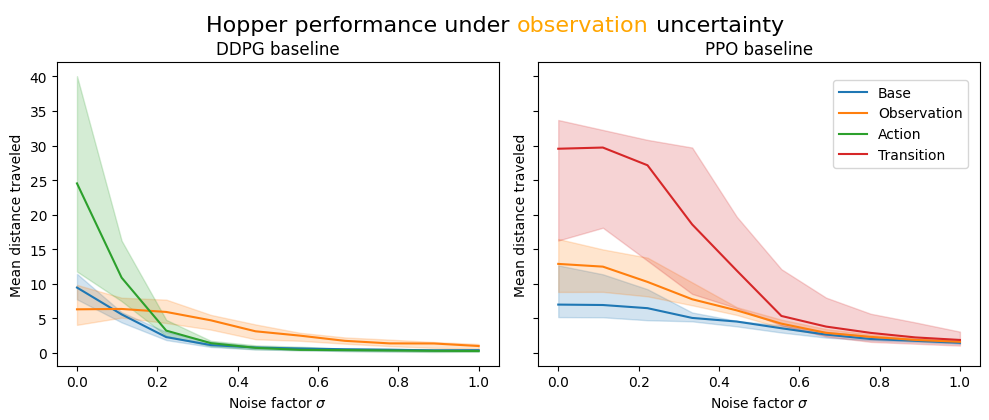

In [32]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Hopper performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("observation",
              textprops=dict(color="orange", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["state"], axes[0], "Base")
plot_data_median(state_distances["state"], axes[0], "Observation")
plot_data_median(action_distances["state"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["state"], axes[1], "Base")
plot_data_median(stateppo_distances["state"], axes[1], "Observation")
# plot_data(actionppo_distances["state"], axes[1], "Action")
plot_data_median(transition_distances["state"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

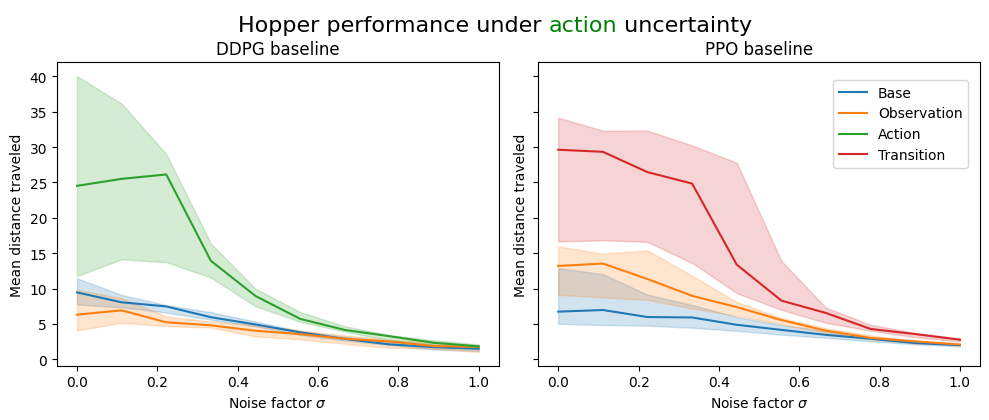

In [33]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Hopper performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("action",
              textprops=dict(color="green", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["action"], axes[0], "Base")
plot_data_median(state_distances["action"], axes[0], "Observation")
plot_data_median(action_distances["action"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["action"], axes[1], "Base")
plot_data_median(stateppo_distances["action"], axes[1], "Observation")
# plot_data(actionppo_distances["action"], axes[1], "Action")
plot_data_median(transition_distances["action"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

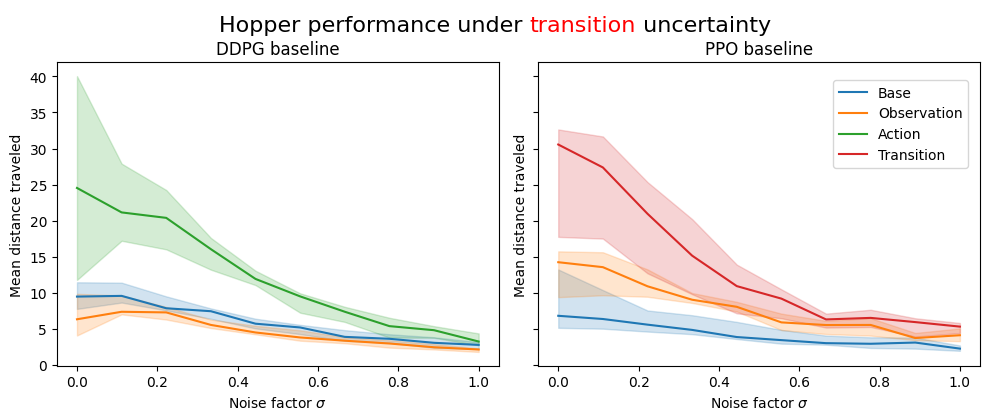

In [34]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Hopper performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("transition",
              textprops=dict(color="red", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["transition"], axes[0], "Base")
plot_data_median(state_distances["transition"], axes[0], "Observation")
plot_data_median(action_distances["transition"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["transition"], axes[1], "Base")
plot_data_median(stateppo_distances["transition"], axes[1], "Observation")
# plot_data(actionppo_distances["transition"], axes[1], "Action")
plot_data_median(transition_distances["transition"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

#### Walker Task

In [35]:
base_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_base_agent_Walker2d-v5.json"))
baseppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_baseppo_agent_Walker2d-v5.json"))
state_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_state_agent_Walker2d-v5.json"))
stateppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_stateppo_agent_Walker2d-v5.json"))
action_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_action_agent_Walker2d-v5.json"))
# actionppo_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_actionppo_agent_Walker2d-v5.json"))
transition_distances = make_numpy_arrays(process_results("../results/single_noise/singlenoise_transition_agent_Walker2d-v5.json"))

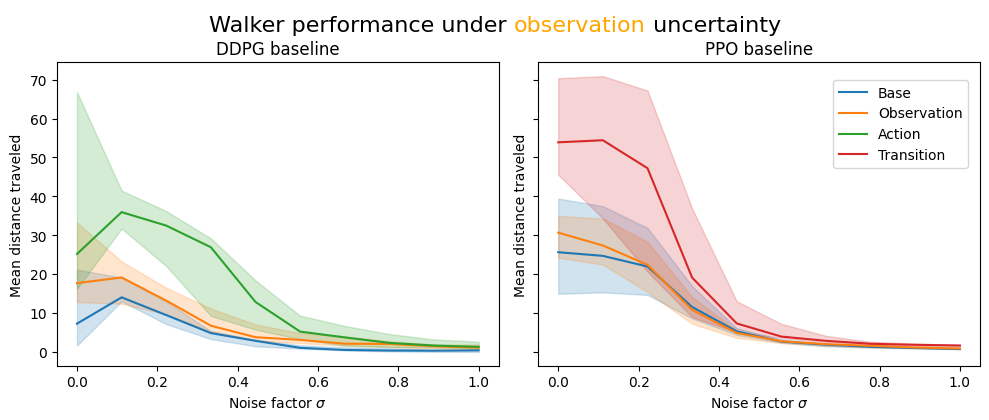

In [36]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Walker performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("observation",
              textprops=dict(color="orange", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["state"], axes[0], "Base")
plot_data_median(state_distances["state"], axes[0], "Observation")
plot_data_median(action_distances["state"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["state"], axes[1], "Base")
plot_data_median(stateppo_distances["state"], axes[1], "Observation")
# plot_data(actionppo_distances["state"], axes[1], "Action")
plot_data_median(transition_distances["state"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

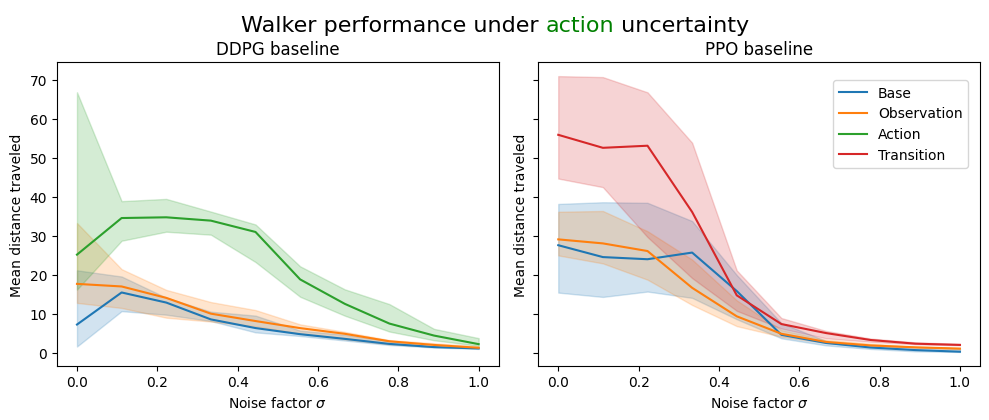

In [37]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Walker performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("action",
              textprops=dict(color="green", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["action"], axes[0], "Base")
plot_data_median(state_distances["action"], axes[0], "Observation")
plot_data_median(action_distances["action"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["action"], axes[1], "Base")
plot_data_median(stateppo_distances["action"], axes[1], "Observation")
# plot_data(actionppo_distances["action"], axes[1], "Action")
plot_data_median(transition_distances["action"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()

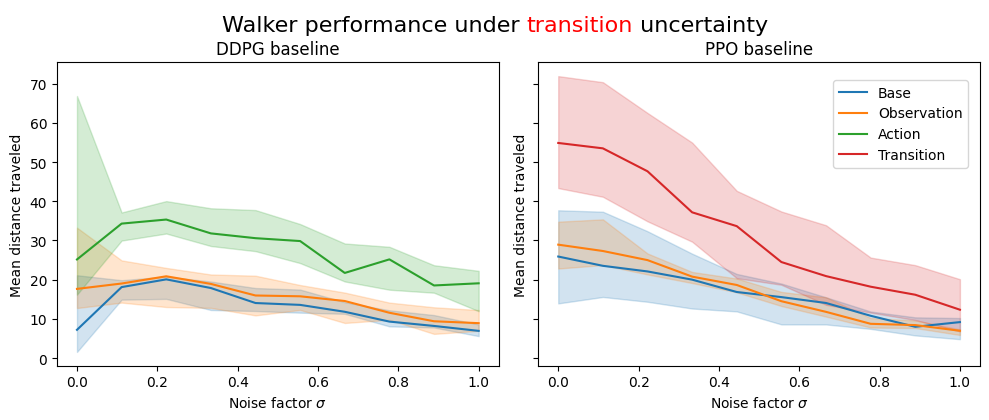

In [38]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

title_size = 16  # similar to default suptitle size

t1 = TextArea("Walker performance under ",
              textprops=dict(fontsize=title_size))
t2 = TextArea("transition",
              textprops=dict(color="red", fontsize=title_size))
t3 = TextArea(" uncertainty",
              textprops=dict(fontsize=title_size))

box = HPacker(children=[t1, t2, t3], align="center", pad=0, sep=0)

anchored_box = AnchoredOffsetbox(
    loc="upper center",
    child=box,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),   # move title higher
    bbox_transform=fig.transFigure,
    borderpad=0
)

fig.add_artist(anchored_box)

# First subplot
plot_data_median(base_distances["transition"], axes[0], "Base")
plot_data_median(state_distances["transition"], axes[0], "Observation")
plot_data_median(action_distances["transition"], axes[0], "Action")
axes[0].set_title("DDPG baseline")

# Second subplot
plot_data_median(baseppo_distances["transition"], axes[1], "Base")
plot_data_median(stateppo_distances["transition"], axes[1], "Observation")
# plot_data(actionppo_distances["transition"], axes[1], "Action")
plot_data_median(transition_distances["transition"], axes[1], "Transition")
axes[1].set_title("PPO baseline")

# Add legends only once (optional)
# Add legends only once (optional)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# remove duplicates while preserving order
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper right",
    bbox_to_anchor=(0.98, 0.88),  # tweak as needed
    frameon=True
)

plt.tight_layout()
plt.show()